In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus']=False

In [4]:
df=pd.read_csv('2003-2025 Data_cleaned.csv')
print(f"data shape:{df.shape}")
print(df[['Year','Round','DD','Quality']].head())
print(df[["Year","Round","DD","Quality"]].isnull().sum())

data shape:(5140, 11)
   Year  Round   DD  Quality
0  2003  Final  3.2     25.0
1  2003  Final  3.2     20.0
2  2003  Final  3.3     25.5
3  2003  Final  3.0     27.0
4  2003  Final  3.4     28.5
Year       0
Round      0
DD         0
Quality    0
dtype: int64


In [16]:
#区分决赛Final和预赛Pre
def classify_competition_type(round_name):
    if pd.isna(round_name):
        return "Don't Know"
    round_str=str(round_name).lower()
    if any(keyword in round_str for keyword in ['final']):
        return "Final"
    elif any(keyword in round_str for keyword in ["pre","preliminary"]):
        return "Pre"
    else:
        return "Don't Know"
df["Competition Type"]=df['Round'].apply(classify_competition_type)

def classify_olympic_cycle(year):
    if 2003<=year<=2008:
        return "2003-2008 (Olympic Cycle 1)"
    elif 2009<=year<=2016:
        return "2009-2016 (Olympic Cycle 2)"
    elif 2017<=year<=2024:
        return "2017-2024 (Olympic Cycle 3)"
    else:
        return "Other Year"
df["Olympic Cycle"]=df['Year'].apply(classify_olympic_cycle)

df_valid=df[(df["Competition Type"].isin(["Final",'Pre']))&(df["Olympic Cycle"]!="Other Year")&(df["DD"].notnull())].copy()

print(f"after processing Data's shape:{df_valid.shape}")
print(f"\nData distribution of competition types in each Olympic cycle:")
print(df_valid.groupby(["Olympic Cycle","Competition Type"]).size().unstack(fill_value=0))

after processing Data's shape:(4900, 13)

Data distribution of competition types in each Olympic cycle:
Competition Type             Final   Pre
Olympic Cycle                           
2003-2008 (Olympic Cycle 1)    295   935
2009-2016 (Olympic Cycle 2)    470  1325
2017-2024 (Olympic Cycle 3)    480  1395


In [17]:
yearly_dd=df_valid.groupby(['Year','Competition Type'])['DD'].agg(['mean','max','count']).reset_index()
print(yearly_dd[yearly_dd['count']>=5])

    Year Competition Type      mean  max  count
0   2003            Final  3.075000  3.4     60
1   2003              Pre  2.995789  3.6    190
2   2004            Final  3.111667  3.5     60
3   2004              Pre  2.970698  3.6    215
4   2005            Final  2.656667  3.4     60
5   2005              Pre  3.057778  3.4    135
6   2007            Final  3.172727  3.6     55
7   2007              Pre  3.076250  3.6    160
8   2008            Final  3.201667  3.6     60
9   2008              Pre  3.035745  3.6    235
10  2009            Final  3.146667  3.4     60
11  2009              Pre  3.084516  3.6    155
12  2010            Final  3.131667  3.3     60
13  2010              Pre  3.072174  3.3    115
14  2011            Final  3.143333  3.3     60
15  2011              Pre  3.058750  3.3    160
16  2012            Final  3.115000  3.3     60
17  2012              Pre  3.042564  3.3    195
18  2013            Final  3.086000  3.6     50
19  2013              Pre  3.044444  3.6

In [18]:
cycle_dd = df_valid.groupby(['Olympic Cycle', 'Competition Type'])['DD'].agg(['mean','std','max','median', 'count']).round(3)
print(cycle_dd)

                                               mean    std  max  median  count
Olympic Cycle               Competition Type                                  
2003-2008 (Olympic Cycle 1) Final             3.041  0.380  3.6     3.2    295
                            Pre               3.023  0.273  3.6     3.0    935
2009-2016 (Olympic Cycle 2) Final             3.126  0.179  3.7     3.2    470
                            Pre               3.050  0.228  3.7     3.1   1325
2017-2024 (Olympic Cycle 3) Final             3.105  0.176  3.7     3.2    480
                            Pre               3.028  0.227  3.6     3.0   1395


In [19]:
quantile_dd = df_valid.groupby(['Olympic Cycle', 'Competition Type'])['DD'].quantile([0.25, 0.5, 0.75]).unstack()
print(quantile_dd.round(3))

                                              0.25  0.50  0.75
Olympic Cycle               Competition Type                  
2003-2008 (Olympic Cycle 1) Final              2.9   3.2   3.3
                            Pre                2.8   3.0   3.2
2009-2016 (Olympic Cycle 2) Final              3.0   3.2   3.2
                            Pre                2.9   3.1   3.2
2017-2024 (Olympic Cycle 3) Final              3.0   3.2   3.2
                            Pre                2.9   3.0   3.2


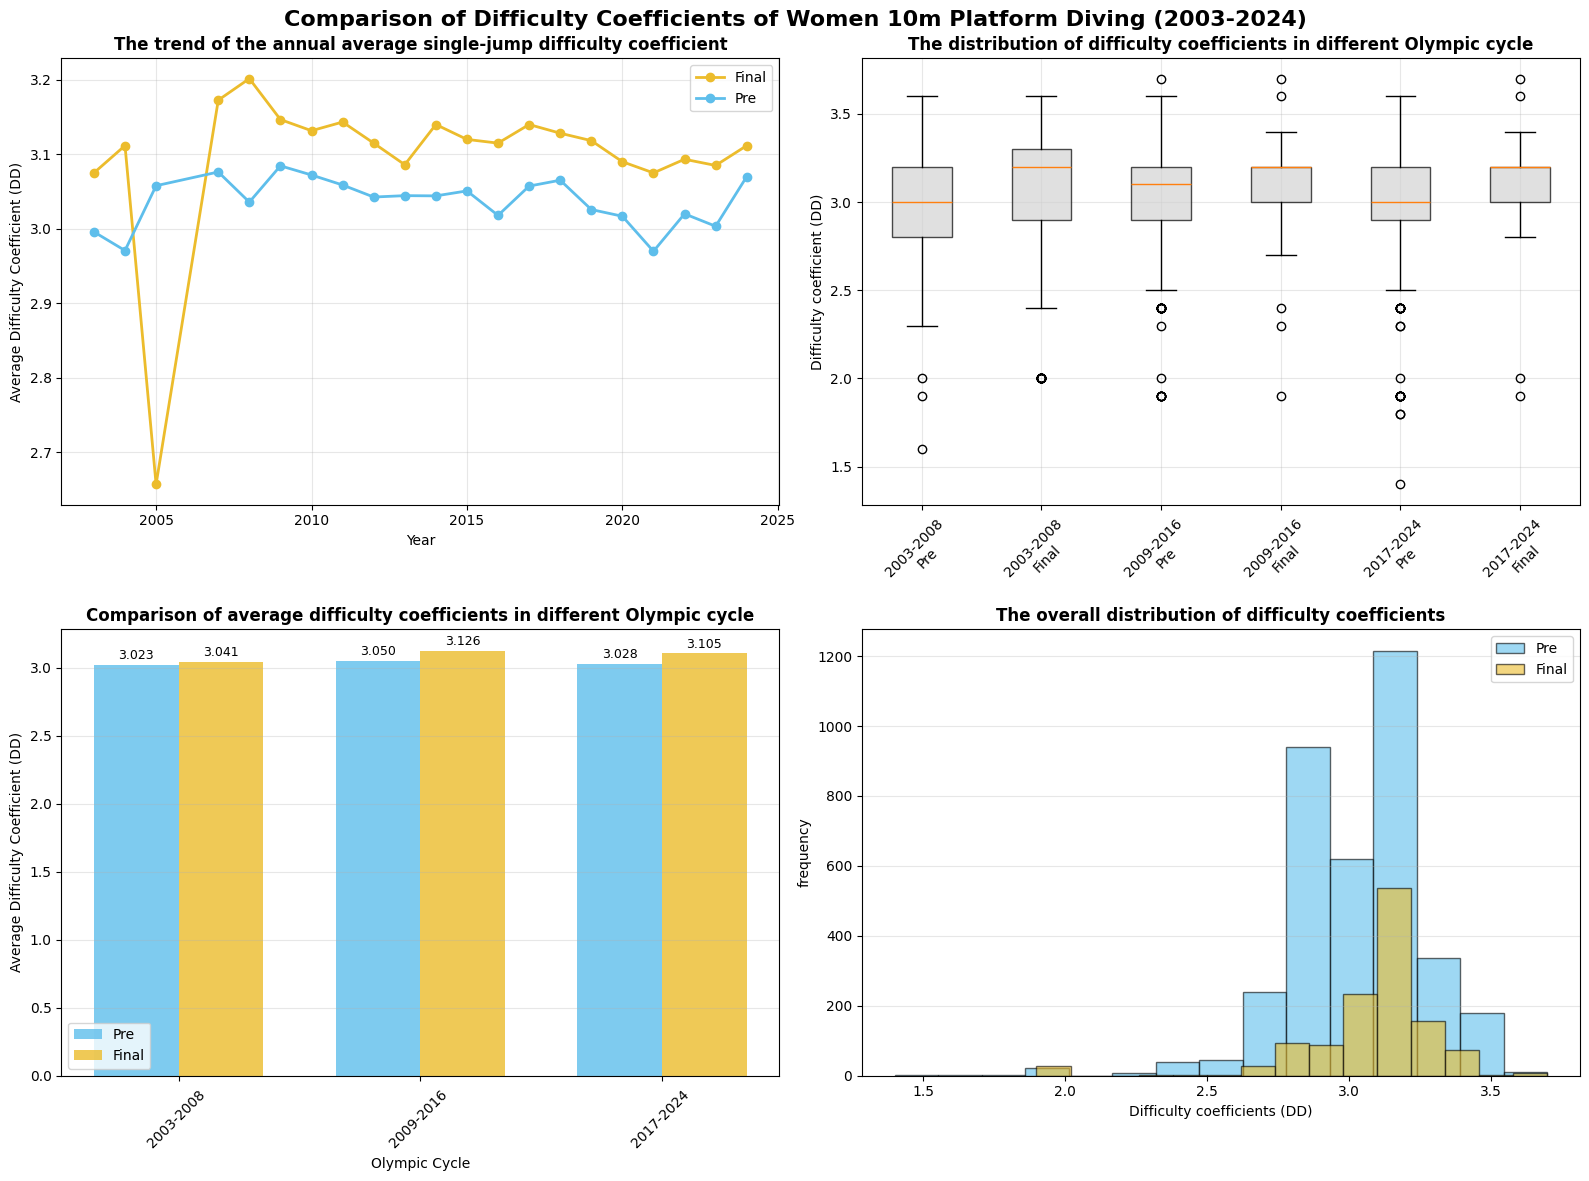


picture has been saved to: Comparison analysis of Women 10m Platform Single Jump.png
None


In [26]:
fig,axes=plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Comparison of Difficulty Coefficients of Women 10m Platform Diving (2003-2024)',fontsize=16,fontweight='bold')

colors={'Final':"#ECBC2C",'Pre':"#5EBEEB"}
cycle_order=["2003-2008 (Olympic Cycle 1)","2009-2016 (Olympic Cycle 2)","2017-2024 (Olympic Cycle 3)"]

#Annual average difficulty trend
ax1 = axes[0, 0]
for comp_type in ['Final', 'Pre']:
    data = yearly_dd[yearly_dd['Competition Type'] == comp_type]
    # Only plot the years with a data volume of ≥5 (avoid outliers with too few samples)
    data_valid = data[data['count'] >= 5]
    ax1.plot(data_valid['Year'], data_valid['mean'], 
             marker='o', linewidth=2, label=comp_type, color=colors[comp_type])
ax1.set_title('The trend of the annual average single-jump difficulty coefficient', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Difficulty Coefficient (DD)')
ax1.legend()
ax1.grid(alpha=0.3)
 
#Box plots of difficulty for different Olympic cycle 
ax2 = axes[0, 1]
box_data = []
box_labels = []
for cycle in cycle_order:
    for comp_type in ['Pre', 'Final']:
        dd_data = df_valid[(df_valid['Olympic Cycle'] == cycle) & (df_valid['Competition Type'] == comp_type)]['DD']
        if len(dd_data) >= 0:  
            box_data.append(dd_data)
            box_labels.append(f"{cycle.split('(')[0]}\n{comp_type}")
ax2.boxplot(box_data, labels=box_labels, patch_artist=True,
            boxprops=dict(facecolor='lightgray', alpha=0.7))
ax2.set_title('The distribution of difficulty coefficients in different Olympic cycle', fontweight='bold')
ax2.set_ylabel('Difficulty coefficient (DD)')
ax2.tick_params(axis='x', rotation=45) 
ax2.grid(alpha=0.3)

#Bar charts of average difficulty in different Olympic cycle 
ax3 = axes[1, 0]
x_pos = np.arange(len(cycle_order))
width = 0.35 
for i, comp_type in enumerate(['Pre', 'Final']):
    mean_dd = [cycle_dd.loc[(cycle, comp_type), 'mean'] if (cycle, comp_type) in cycle_dd.index else 0 
               for cycle in cycle_order]

    bars = ax3.bar(x_pos + (i - 0.5) * width, mean_dd, width, 
                   label=comp_type, color=colors[comp_type], alpha=0.8)
    
    for bar, value in zip(bars, mean_dd):
        if value > 0:
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{value:.3f}', ha='center', va='bottom', fontsize=9)
ax3.set_title('Comparison of average difficulty coefficients in different Olympic cycle', fontweight='bold')
ax3.set_xlabel('Olympic Cycle')
ax3.set_ylabel('Average Difficulty Coefficient (DD)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([cycle.split('(')[0] for cycle in cycle_order], rotation=45)
ax3.legend()
ax3.grid(alpha=0.3, axis='y')

#Histogram of Difficulty Coefficient Distribution
ax4 = axes[1, 1]
for comp_type in ['Pre', 'Final']:
    data = df_valid[df_valid['Competition Type'] == comp_type]['DD']
    ax4.hist(data, bins=15, alpha=0.6, label=comp_type, color=colors[comp_type], edgecolor='black')
ax4.set_title('The overall distribution of difficulty coefficients', fontweight='bold')
ax4.set_xlabel('Difficulty coefficients (DD)')
ax4.set_ylabel('frequency')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Comparison analysis of Women 10m Platform Single Jump.png', dpi=300, bbox_inches='tight')
plt.show()
print(print("\npicture has been saved to: Comparison analysis of Women 10m Platform Single Jump.png"))